# Import

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Read data
charging_sessions = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DSO 528/Final Project/charging-sessions.csv')
emissions = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DSO 528/Final Project/emissions.csv')
vehicle_sales = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DSO 528/Final Project/vehicle-sales-volumes-by-price.csv')

In [ ]:
# Charging Sessions data
charging_sessions['timestamp_pt'] = pd.to_datetime(charging_sessions['timestamp_pt'])
charging_sessions['start_date_time_pt'] = pd.to_datetime(charging_sessions['start_date_time_pt'])
charging_sessions['stop_date_time_pt'] = pd.to_datetime(charging_sessions['stop_date_time_pt'])

print('Charging Sessions dtypes:')
print(charging_sessions.dtypes)
charging_sessions.head()

Charging Sessions dtypes:
charger_id                           int64
timestamp_pt                datetime64[ns]
start_date_time_pt          datetime64[ns]
stop_date_time_pt           datetime64[ns]
session_duration_minutes           float64
kwh_delivered                      float64
dtype: object


,charger_id,timestamp_pt,start_date_time_pt,stop_date_time_pt,session_duration_minutes,kwh_delivered
0,0,2024-01-01 10:00:00,2024-01-01 10:33:41.575,2024-01-01 16:02:22.666,328.68,10.5524
1,1,2024-01-02 17:00:00,2024-01-02 17:30:40.783,2024-01-02 20:19:43.098,169.03,25.8684
2,2,2024-01-03 08:00:00,2024-01-03 08:18:27.760,2024-01-03 15:13:03.206,414.58,30.8929
3,3,2024-01-04 21:00:00,2024-01-04 21:00:55.672,2024-01-05 08:48:03.000,707.12,48.4611
4,4,2024-01-05 13:00:00,2024-01-05 13:06:10.320,2024-01-05 17:07:09.554,240.98,17.6947


In [ ]:
# Emissions data
emissions['timestamp_pt'] = pd.to_datetime(emissions['timestamp_pt'])
emissions = emissions.sort_values('timestamp_pt').reset_index(drop=True)

print('Emissions dtypes:')
print(emissions.dtypes)
emissions.head()

/tmp/ipython-input-478105029.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  emissions['timestamp_pt'] = pd.to_datetime(emissions['timestamp_pt'])


Emissions dtypes:
id                              int64
timestamp_pt           datetime64[ns]
month                           int64
weekday                         int64
hour                            int64
weekend                          bool
avg_lbs_co2_per_kwh           float64
dtype: object


,id,timestamp_pt,month,weekday,hour,weekend,avg_lbs_co2_per_kwh
0,0,2022-12-31 16:00:00,1,6,0,True,0.995667
1,1,2022-12-31 17:00:00,1,6,1,True,0.991000
2,2,2022-12-31 18:00:00,1,6,2,True,0.997833
3,3,2022-12-31 19:00:00,1,6,3,True,0.973083
4,4,2022-12-31 20:00:00,1,6,4,True,0.969250


In [ ]:
# Vehicle Sales data
print('Vehicle Sales dtypes:')
print(vehicle_sales.dtypes)
vehicle_sales.head()

Vehicle Sales dtypes:
Price Low                   int64
Price High                  int64
Averge Monthly Payment      int64
Sales Volume (thousands)    int64
dtype: object


,Price Low,Price High,Averge Monthly Payment,Sales Volume (thousands)
0,30000,35000,432,1536
1,35000,40000,499,1333
2,40000,45000,565,1007
3,45000,50000,632,925
4,50000,55000,698,798


# EDA

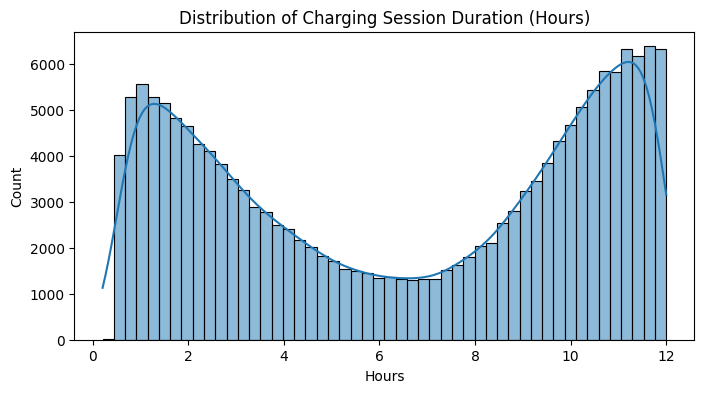

In [ ]:
# Compute duration in hours
charging_sessions['duration_hours'] = charging_sessions['session_duration_minutes'] / 60

# Distribution of charging session duration
plt.figure(figsize=(8,4))
sns.histplot(charging_sessions['duration_hours'], bins=50, kde=True)
plt.title('Distribution of Charging Session Duration (Hours)')
plt.xlabel('Hours')
plt.ylabel('Count')
plt.show()

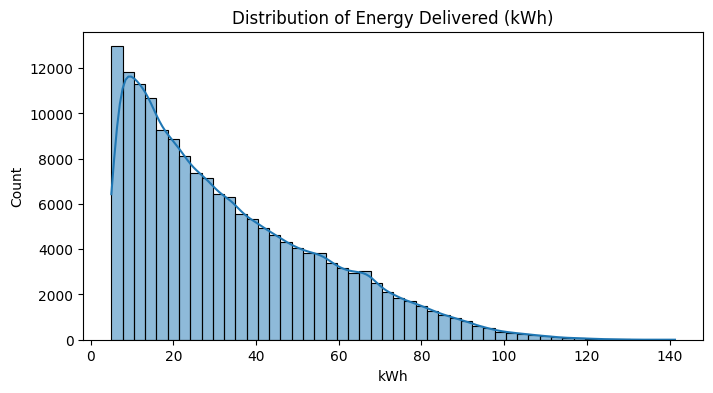

In [ ]:
# Distribution of energy delivered
plt.figure(figsize=(8,4))
sns.histplot(charging_sessions['kwh_delivered'], bins=50, kde=True)
plt.title('Distribution of Energy Delivered (kWh)')
plt.xlabel('kWh')
plt.ylabel('Count')
plt.show()

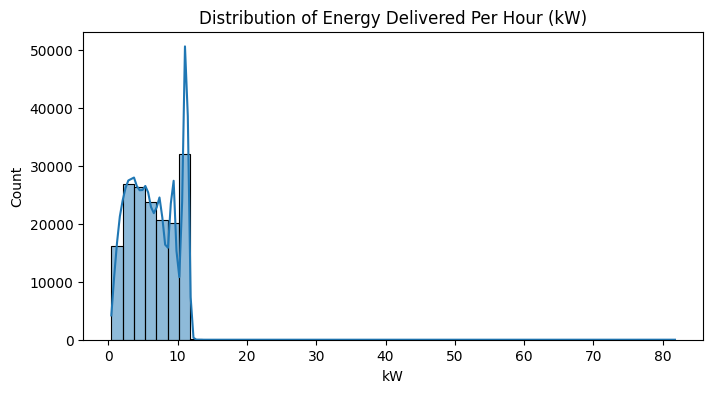

In [ ]:
# Compute energy deliverd per hour
charging_sessions['kwh_per_hour'] = charging_sessions['kwh_delivered'] / charging_sessions['duration_hours']

# Distribution of energy delivered per hour
plt.figure(figsize=(8,4))
sns.histplot(charging_sessions['kwh_per_hour'], bins=50, kde=True)
plt.title('Distribution of Energy Delivered Per Hour (kW)')
plt.xlabel('kW')
plt.ylabel('Count')
plt.show()

Most EVs charge between ~3.5–11 kW at home, which is consistent with the graph.

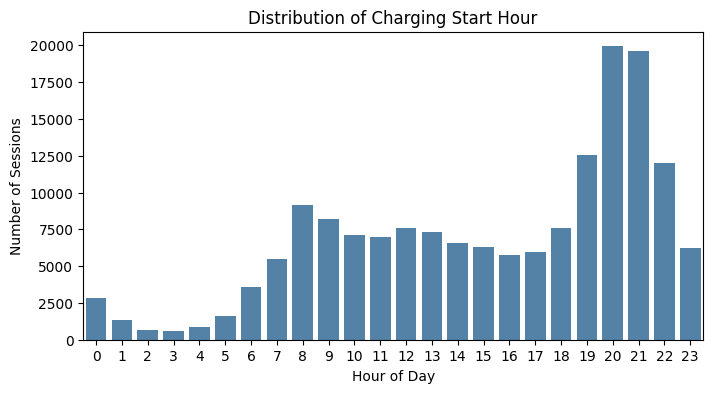

In [ ]:
# Extract hour from the true start time
charging_sessions['start_hour'] = charging_sessions['start_date_time_pt'].dt.hour

# Distribution of charging start hour
plt.figure(figsize=(8,4))
sns.countplot(x='start_hour', data=charging_sessions, color='steelblue')
plt.title('Distribution of Charging Start Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Sessions')
plt.show()

Most charging starts from 7 PM to 10 PM. This overlaps with peak dirty hours.

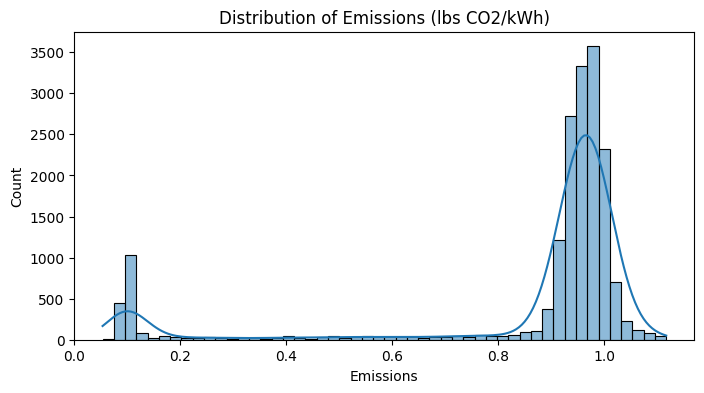

In [ ]:
# Distribution of emission values
plt.figure(figsize=(8,4))
sns.histplot(emissions['avg_lbs_co2_per_kwh'], bins=50, kde=True)
plt.title('Distribution of Emissions (lbs CO2/kWh)')
plt.xlabel('Emissions')
plt.ylabel('Count')
plt.show()

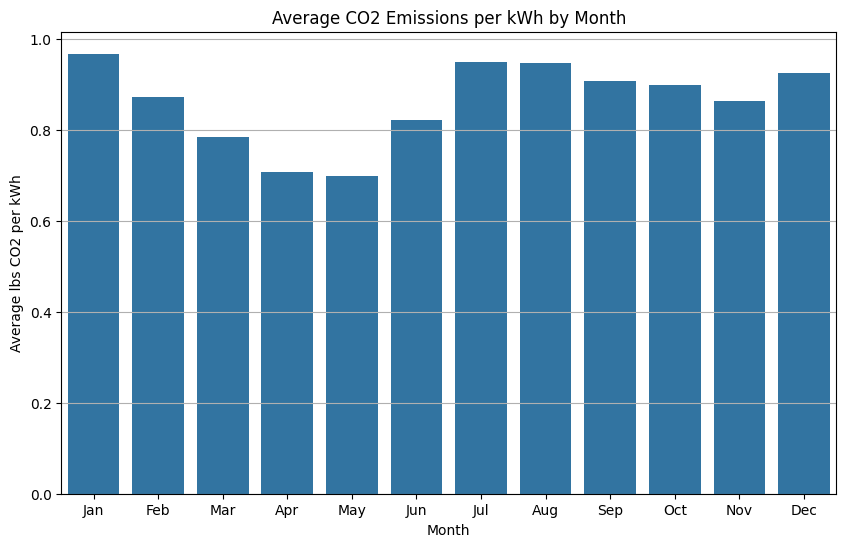

In [ ]:
# Distribution of emissions over month
plt.figure(figsize=(10, 6))
sns.barplot(x='month', y='avg_lbs_co2_per_kwh', data=emissions.groupby('month')['avg_lbs_co2_per_kwh'].mean().reset_index())
plt.title('Average CO2 Emissions per kWh by Month')
plt.xlabel('Month')
plt.xticks(range(0, 12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.ylabel('Average lbs CO2 per kWh')
plt.grid(axis='y')
plt.show()

Emissions are low in spring and summer months when the solar power is high, and high in winter when the solar power is low.

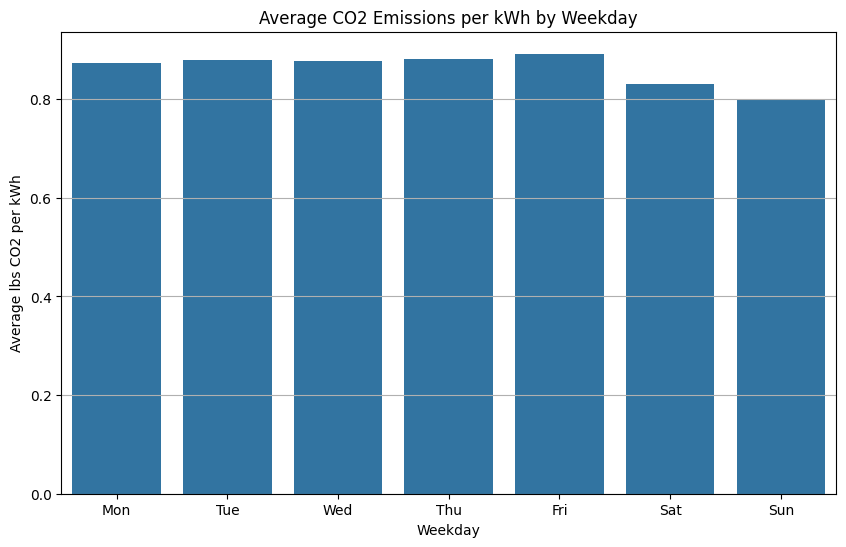

In [ ]:
# Distribution of emissions over weekday
plt.figure(figsize=(10, 6))
sns.barplot(x='weekday', y='avg_lbs_co2_per_kwh', data=emissions.groupby('weekday')['avg_lbs_co2_per_kwh'].mean().reset_index())
plt.title('Average CO2 Emissions per kWh by Weekday')
plt.xlabel('Weekday')
plt.xticks(range(0, 7), ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.ylabel('Average lbs CO2 per kWh')
plt.grid(axis='y')
plt.show()

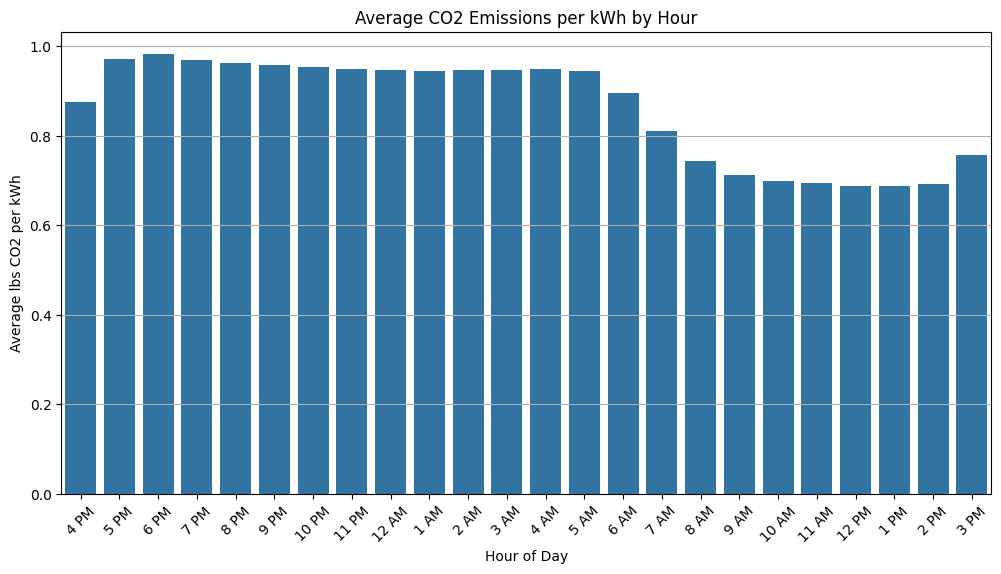

In [ ]:
# Distribution of emissions over hour
plt.figure(figsize=(12, 6))
sns.barplot(x='hour', y='avg_lbs_co2_per_kwh', data=emissions.groupby('hour')['avg_lbs_co2_per_kwh'].mean().reset_index())
plt.title('Average CO2 Emissions per kWh by Hour')
plt.xlabel('Hour of Day')
plt.xticks(range(0, 24), ['4 PM', '5 PM', '6 PM', '7 PM', '8 PM', '9 PM', '10 PM', '11 PM', '12 AM', '1 AM', '2 AM', '3 AM', '4 AM', '5 AM', '6 AM', '7 AM', '8 AM', '9 AM', '10 AM', '11 AM', '12 PM', '1 PM', '2 PM', '3 PM'], rotation=45)
plt.ylabel('Average lbs CO2 per kWh')
plt.grid(axis='y')
plt.show()

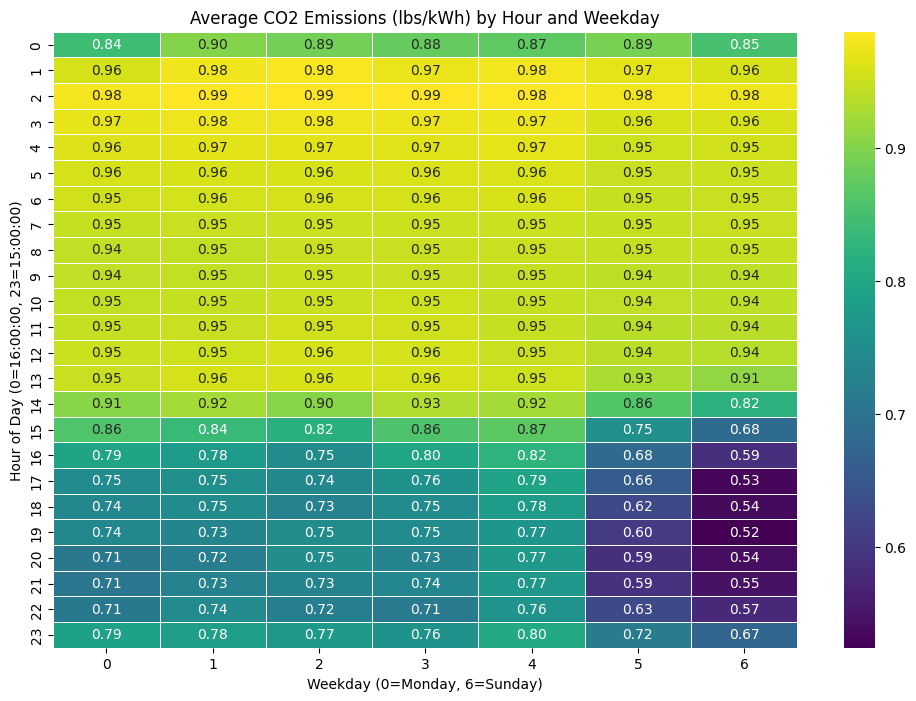

In [ ]:
# Create a pivot table for the heatmap
emissions_heatmap_data = emissions.pivot_table(index='hour', columns='weekday', values='avg_lbs_co2_per_kwh', aggfunc='mean')

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(emissions_heatmap_data, cmap='viridis', annot=True, fmt=".2f", linewidths=.5)
plt.title('Average CO2 Emissions (lbs/kWh) by Hour and Weekday')
plt.xlabel('Weekday (0=Monday, 6=Sunday)')
plt.ylabel('Hour of Day (0=16:00:00, 23=15:00:00)')
plt.show()

**Interpretation**

* Early morning (12–5 AM) and evening (5–11 PM) hours have the **highest CO₂ intensity**. There is more natural gas generation from low solar output and high demand.

* Midday and early afternoon hours (9 AM–2 PM) are consistently **cleanest** across the grid. This is because of strong solar generation and moderate demand.

* Weekend afternoons show **significantly lower emissions** (as low as 0.52–0.60). Lower demand and strong renewable output increases the renewable share.

**Implications for Smart Charging**

* **Hour of day** is the most important predictor of grid cleanliness.

* **Weekday vs. weekend** strongly influences emissions levels.

* Delaying charging (shifting the charging start time forward by 8 hours) is most effective when plug-ins occur during **dirty periods** (evenings/late nights) and the delayed window (the candidate alternative time window) falls into **clean afternoon hours**.

* Delaying is not beneficial if charging already begins in a clean afternoon window.

# Modeling

## Compute A & B windows and label delay

In [ ]:
# Keep only 2023 rows for training
em_2023 = emissions[emissions['timestamp_pt'].dt.year == 2023].reset_index(drop=True)

# Compute A (next 8 hours) and B (8–16h)
s = em_2023['avg_lbs_co2_per_kwh'].to_numpy()
n = len(s)

A = np.full(n, np.nan)  # avg emissions in hours [t, t+8)
B = np.full(n, np.nan)  # avg emissions in hours [t+8, t+16)

for i in range(n):
    # Need a full 16-hour window ahead
    if i + 16 <= n:
        A[i] = s[i : i + 8].mean()
        B[i] = s[i + 8 : i + 16].mean()

em_2023['A_avg_8h'] = A
em_2023['B_avg_8h'] = B

# Drop rows where we couldn't compute both windows
em_2023_labeled = em_2023.dropna(subset=['A_avg_8h', 'B_avg_8h']).copy()

# Create the delay label
# If B < 0.9 * A → delay charging (delay = 1)
# Else → charge immediately (delay = 0)

em_2023_labeled['delay'] = (
    em_2023_labeled['B_avg_8h'] < 0.9 * em_2023_labeled['A_avg_8h']
).astype(int)

# Check distribution of labels
print(em_2023_labeled['delay'].value_counts(normalize=True))

# Check sample rows
em_2023_labeled.head()

delay
0    0.83968
1    0.16032
Name: proportion, dtype: float64


,id,timestamp_pt,month,weekday,hour,weekend,avg_lbs_co2_per_kwh,A_avg_8h,B_avg_8h,delay
0,8,2023-01-01 00:00:00,1,6,8,True,0.957667,0.980958,1.025552,0
1,9,2023-01-01 01:00:00,1,6,9,True,0.958083,0.998042,1.013260,0
2,10,2023-01-01 02:00:00,1,6,10,True,0.956333,1.014708,1.001708,0
3,11,2023-01-01 03:00:00,1,6,11,True,0.955833,1.022010,0.999906,0
4,12,2023-01-01 04:00:00,1,6,12,True,0.959250,1.026792,0.999510,0


84% of the time is no-delay → charging now is better or the same.

16% of the time is delay → delaying charging by 8 hours reduces emissions by ≥10%.

The dataset is imbalanced, with most hours not benefiting from delay.

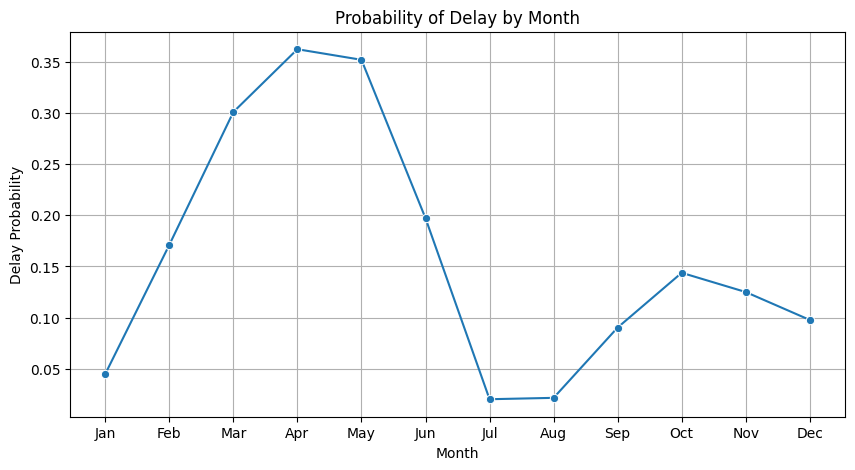

In [ ]:
# Delay rate by month
delay_by_month = em_2023_labeled.groupby('month')['delay'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(x='month', y='delay', data=delay_by_month, marker='o')
plt.title('Probability of Delay by Month')
plt.xlabel('Month')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.ylabel('Delay Probability')
plt.grid(True)
plt.show()

Delays are most beneficial from March to June, peaking in April. Delays are almost never beneficial in July and August.

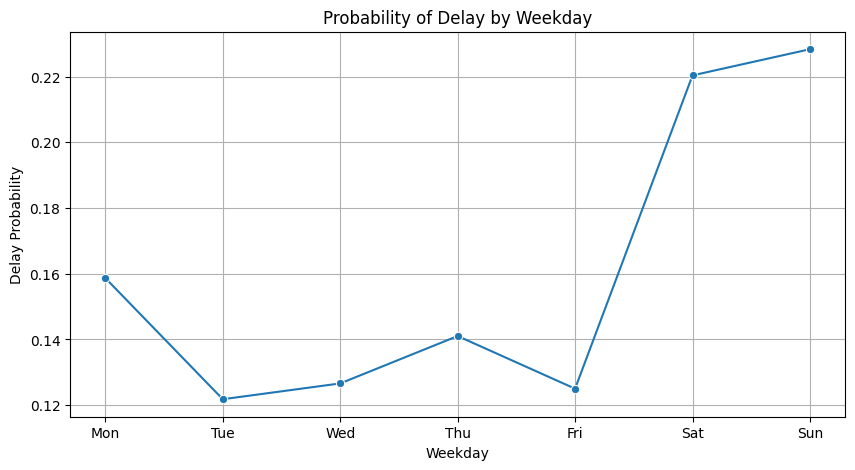

In [ ]:
# Delay rate by weekday
delay_by_weekday = em_2023_labeled.groupby('weekday')['delay'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(x='weekday', y='delay', data=delay_by_weekday, marker='o')
plt.title('Probability of Delay by Weekday')
plt.xlabel('Weekday')
plt.xticks(range(0, 7), ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.ylabel('Delay Probability')
plt.grid(True)
plt.show()

Delay probability is higher on weekends, especially Sunday, because of lower electricity demand across the day. Weekdays have a lower and more stable delay probability.

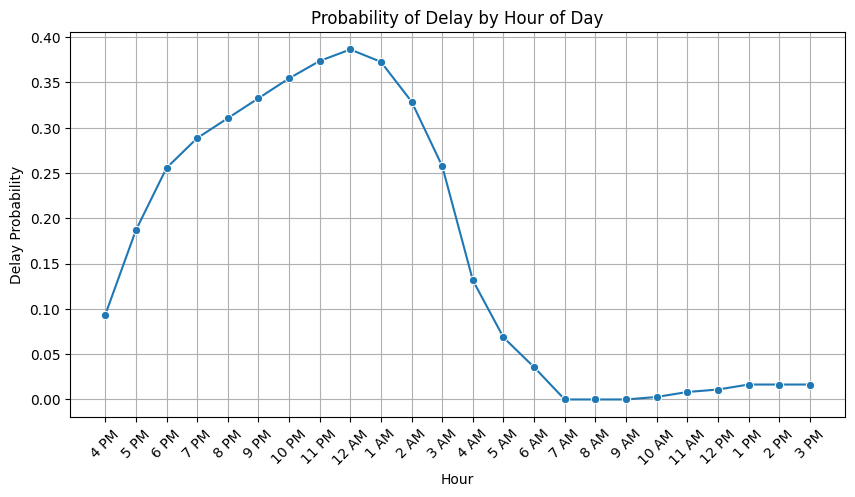

In [ ]:
# Delay rate by hour of day
delay_by_hour = em_2023_labeled.groupby('hour')['delay'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(x='hour', y='delay', data=delay_by_hour, marker='o')
plt.title('Probability of Delay by Hour of Day')
plt.xlabel('Hour')
plt.xticks(range(0, 24), ['4 PM', '5 PM', '6 PM', '7 PM', '8 PM', '9 PM', '10 PM', '11 PM', '12 AM', '1 AM', '2 AM', '3 AM', '4 AM', '5 AM', '6 AM', '7 AM', '8 AM', '9 AM', '10 AM', '11 AM', '12 PM', '1 PM', '2 PM', '3 PM'], rotation=45)
plt.ylabel('Delay Probability')
plt.grid(True)
plt.show()

Delay is most beneficial when the plug-in occurs after 5 PM until 2 AM, because charging immediately would use dirty nighttime electricity, while delaying 8 hours shifts charging into the clean, solar-rich afternoon.

Delay is almost never beneficial when the plug-in occurs between 7 AM and 2 PM, because charging immediately uses clean solar energy, while delaying shifts charging into the dirty evening/night.

## Feature engineering

In [ ]:
# Create a copy to avoid modifying original
df = em_2023_labeled.copy()

In [ ]:
# Lag features (past emissions)
lag_list = [1, 2, 3, 6, 12, 24]

for L in lag_list:
  df[f'lag{L}'] = df['avg_lbs_co2_per_kwh'].shift(L)
  df[f'diff_lag{L}'] = df['avg_lbs_co2_per_kwh'] - df[f'lag{L}']

In [ ]:
# Rolling averages and volatility
roll_windows = [3, 6, 12, 24]

for R in roll_windows:
  df[f'roll_mean_{R}'] = df['avg_lbs_co2_per_kwh'].rolling(R).mean()
  df[f'roll_std_{R}']  = df['avg_lbs_co2_per_kwh'].rolling(R).std()
  df[f'diff_roll{R}'] = df['avg_lbs_co2_per_kwh'] - df[f'roll_mean_{R}']

In [ ]:
# Drop rows where we can’t compute all features yet
df = df.dropna().copy().reset_index(drop=True)

# Define features for training
feature_cols = [
    'month', 'weekday', 'hour', 'weekend',
    'lag1', 'lag3', 'lag6', 'lag12', 'lag24',
    'diff_lag1', 'diff_lag6', 'diff_lag24',
    'roll_mean_6', 'roll_mean_24',
    'roll_std_6', 'roll_std_24',
    'diff_roll6', 'diff_roll24'
]

# Create X and y
X = df[feature_cols]
y = df['delay']

## Model training

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, shuffle=False
)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

X_train shape: (6104, 18)
X_test shape: (2617, 18)
y_train shape: (6104,)
y_test shape: (2617,)


### Logistic Regression (Baseline)

Logistic Regression (Baseline) - Classification Report:
              precision    recall  f1-score   support

           0      0.889     0.987     0.935      2301
           1      0.516     0.101     0.169       316

    accuracy                          0.880      2617
   macro avg      0.702     0.544     0.552      2617
weighted avg      0.844     0.880     0.843      2617



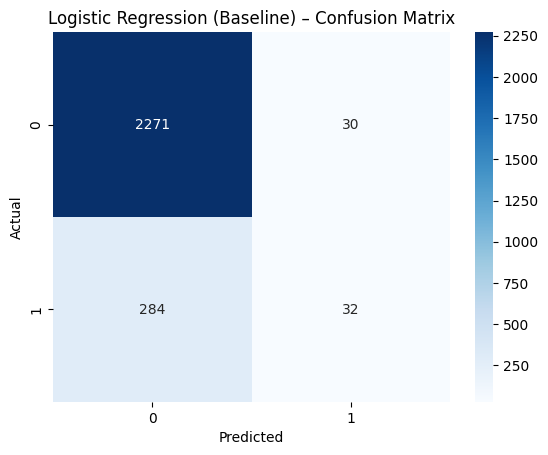

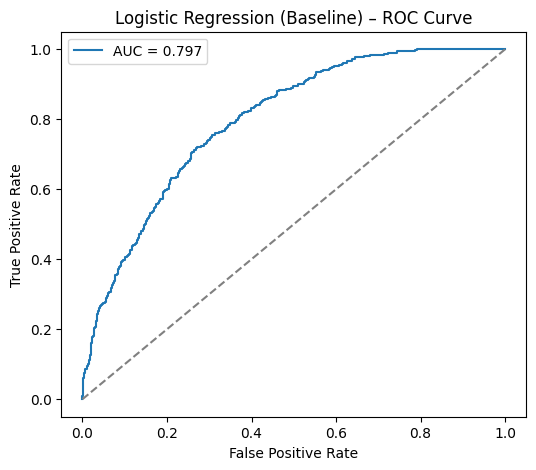

In [ ]:
# Fit the model
logreg = LogisticRegression(max_iter=500)
logreg.fit(X_train, y_train)

# Predictions
y_pred = logreg.predict(X_test)
y_proba = logreg.predict_proba(X_test)[:, 1]

print('Logistic Regression (Baseline) - Classification Report:')
print(classification_report(y_test, y_pred, digits=3))

# Confusion matrix
cm_logit = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_logit, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression (Baseline) – Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression (Baseline) – ROC Curve')
plt.legend()
plt.show()

The baseline logistic regression model identifies immediate-charging periods very well (98.7% recall) but fails to detect most delay opportunities (~10% recall).

The overall accuracy of 88% is misleading, because the dataset is heavily imbalanced: most timestamps do not qualify for delay.

The model lacks the capacity to learn the nonlinear temporal structure of grid emissions.

As a result, it would deliver minimal real-world emissions reduction, since it misses most windows where shifting load would help.

### Logistic Regression (With Interactions)

Logistic Regression (Interactions) - Classification Report:
              precision    recall  f1-score   support

           0      0.894     0.963     0.927      2301
           1      0.380     0.165     0.230       316

    accuracy                          0.867      2617
   macro avg      0.637     0.564     0.578      2617
weighted avg      0.831     0.867     0.843      2617



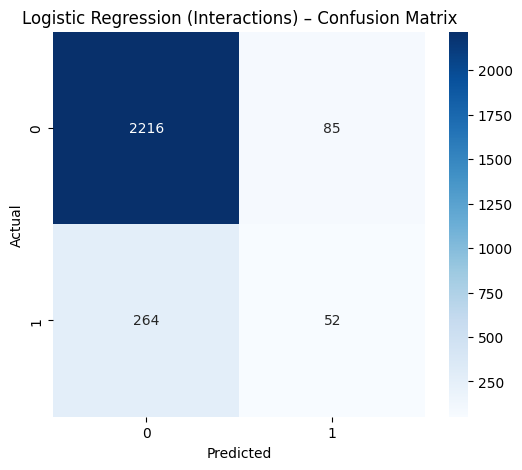

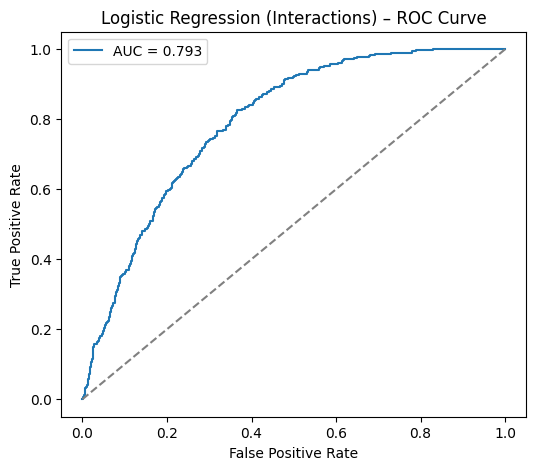

In [ ]:
# Create interaction features (degree 2, interaction only)
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)

X_train_int = poly.fit_transform(X_train)
X_test_int  = poly.transform(X_test)

# Fit the model with interactions
logreg_int = LogisticRegression(max_iter=500, n_jobs=-1)
logreg_int.fit(X_train_int, y_train)

# Predictions
y_pred_int = logreg_int.predict(X_test_int)
y_proba_int = logreg_int.predict_proba(X_test_int)[:, 1]

print('Logistic Regression (Interactions) - Classification Report:')
print(classification_report(y_test, y_pred_int, digits=3))

# Confusion matrix
cm_logit_int = confusion_matrix(y_test, y_pred_int)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_logit_int, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression (Interactions) – Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC
fpr_int, tpr_int, _ = roc_curve(y_test, y_proba_int)
roc_auc_int = auc(fpr_int, tpr_int)

# Plot ROC curve
plt.figure(figsize=(6, 5))
plt.plot(fpr_int, tpr_int, label=f'AUC = {roc_auc_int:.3f}')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression (Interactions) – ROC Curve')
plt.legend()
plt.show()

Recall for class 1 (delay) increased from 10% → 16.5% compared with baseline logistic regression. This shows interactions help the model understand some nonlinear emission patterns (e.g., hour × lag effects), but the improvement is still small.

The model misses 264 out of 316 delay opportunities. This means many charging sessions that should be delayed (cleaner window) are still predicted as “charge now.”

More than half of the predicted delay signals are incorrect (precision 0.38). This indicates the model still cannot cleanly separate emission patterns where B < 0.9A.

ROC AUC stays nearly the same. This confirms that while interactions added complexity, they didn't fundamentally improve the model’s ability to discriminate between clean vs. dirty future windows.

### Random Forest

Random Forest - Classification Report:
              precision    recall  f1-score   support

           0      0.894     0.988     0.939      2301
           1      0.630     0.146     0.237       316

    accuracy                          0.887      2617
   macro avg      0.762     0.567     0.588      2617
weighted avg      0.862     0.887     0.854      2617



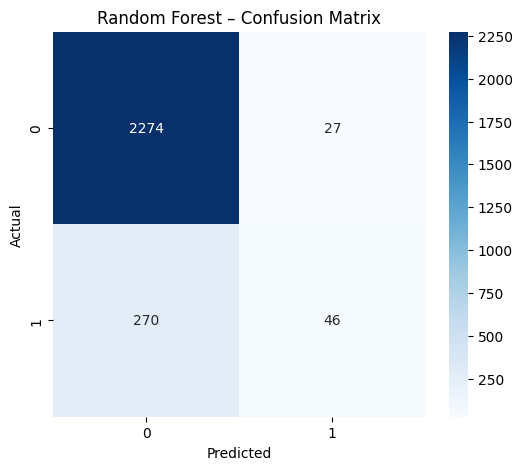

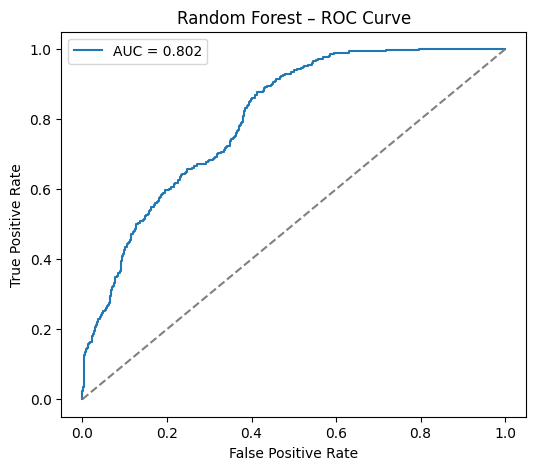

In [ ]:
# Fit the model
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=3,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print('Random Forest - Classification Report:')
print(classification_report(y_test, y_pred_rf, digits=3))

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest – Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Plot ROC curve
plt.figure(figsize=(6, 5))
plt.plot(fpr_rf, tpr_rf, label=f'AUC = {roc_auc_rf:.3f}')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest – ROC Curve')
plt.legend()
plt.show()

Random Forest is very confident and accurate when predicting “charge now” (99% recall, 0.89 precision).

This makes sense because emissions patterns are highly stable during normal grid hours, and the majority class dominates.

The overall accuracy is 0.887, but it is inflated because most sessions are class 0. The model can be wrong on all class 1 cases and still get over 85%. Thus, accuracy is not a meaningful metric for this business problem.

ROC AUC ~0.802 indicates the model has good ranking ability.

The model is very conservative as it rarely recommends delaying charging. This is safe because customers always get full charge, but might miss many opportunities to reduce emissions.

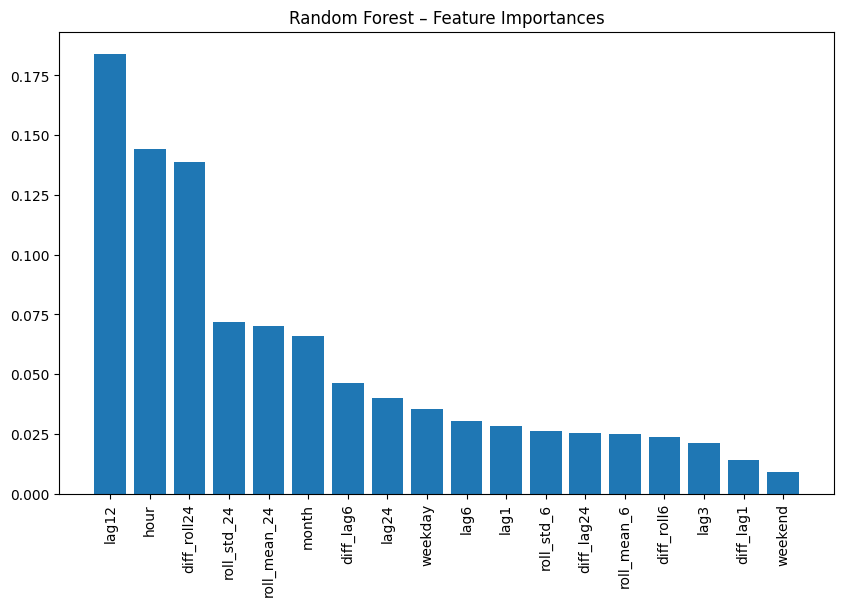

In [ ]:
# Feature importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title('Random Forest – Feature Importances')
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), X_train.columns[indices], rotation=90)
plt.show()

### XGBoost

XGBoost - Classification Report:
              precision    recall  f1-score   support

           0      0.893     0.982     0.935      2301
           1      0.517     0.142     0.223       316

    accuracy                          0.880      2617
   macro avg      0.705     0.562     0.579      2617
weighted avg      0.848     0.880     0.849      2617



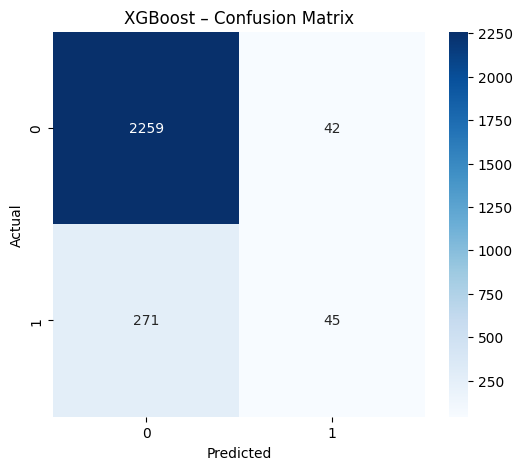

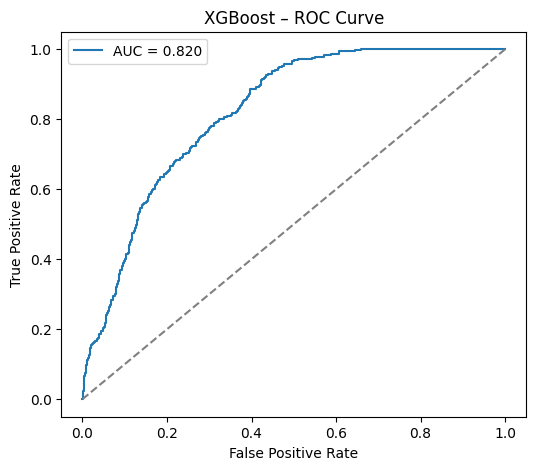

In [ ]:
# Fit the model
xgb = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print('XGBoost - Classification Report:')
print(classification_report(y_test, y_pred_xgb, digits=3))

# Confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues')
plt.title('XGBoost – Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

# Plot ROC curve
plt.figure(figsize=(6, 5))
plt.plot(fpr_xgb, tpr_xgb, label=f'AUC = {roc_auc_xgb:.3f}')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost – ROC Curve')
plt.legend()
plt.show()

XGBoost achieves the highest AUC among all models tested (AUC = 0.820). This means XGBoost is the best at ranking cleaner vs. dirtier future charging windows, even though it still struggles with minority cases.

When XGBoost predicts delay, it's correct ~52% of the time; however, it still misses many opportunities to delay charging (0.142 recall).

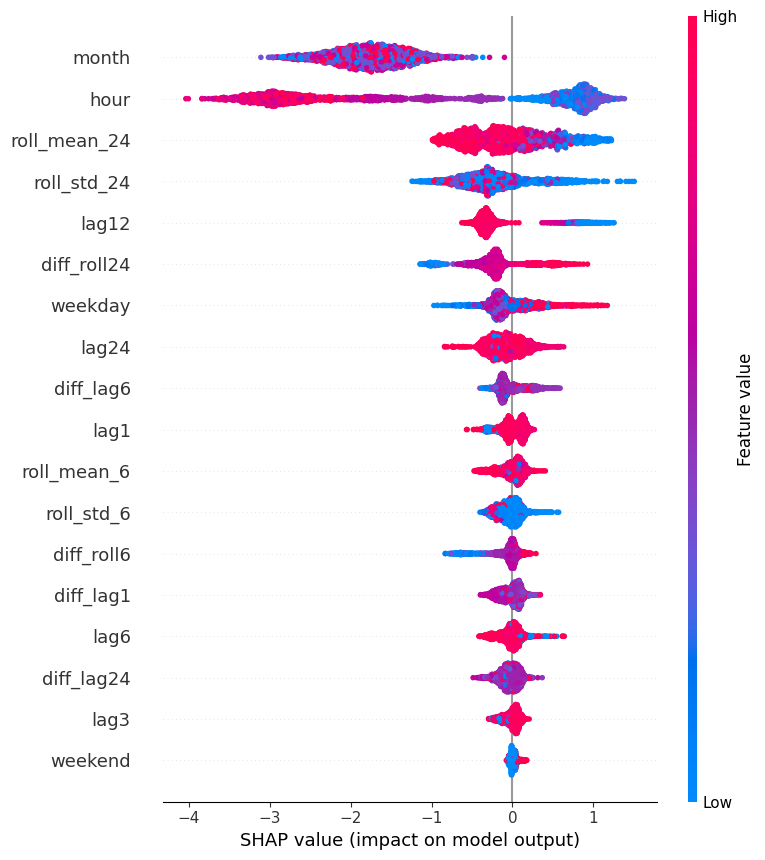

In [ ]:
import shap

# Initialize a SHAP TreeExplainer
explainer = shap.TreeExplainer(xgb)

# Calculate SHAP values for the X_test dataset
shap_values = explainer.shap_values(X_test)

# Plot SHAP values
shap.summary_plot(shap_values, X_test)

## Apply the model to real EV charging sessions in 2024

XGBoost achieved the best model performance. It consistently outperformed logistic models and random forests in separating “clean vs. dirty” charging windows. However, all models—including XGBoost—struggle with class imbalance: they predict “charge now” far more often than “delay.”

### Tune the probability threshold

In [ ]:
from sklearn.metrics import precision_recall_curve, f1_score

# Predict probabilities
y_scores = y_proba_xgb  # xgb.predict_proba(X_test)[:, 1]

# Precision-Recall curve
precisions, recalls, pr_thresholds = precision_recall_curve(y_test, y_scores)

f1_scores = []
for t in pr_thresholds:
    y_pred_at_t = (y_scores >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_at_t))

# Pick the threshold that maximizes F1 for class 1 (delay)
f1_scores = np.array(f1_scores)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = pr_thresholds[optimal_idx]
max_f1_score = f1_scores[optimal_idx]

print(f'Optimal Threshold for F1-score: {optimal_threshold:.4f}')
print(f'Maximum F1-score at this threshold: {max_f1_score:.4f}')

Optimal Threshold for F1-score: 0.0658
Maximum F1-score at this threshold: 0.4309


### Build features + A/B windows for 2024 emissions

In [ ]:
# Keep only 2024 rows for prediction
em_2024 = emissions[emissions['timestamp_pt'].dt.year == 2024].reset_index(drop=True)

# Compute A (next 8 hours) and B (8–16h)
s = em_2024['avg_lbs_co2_per_kwh'].to_numpy()
n = len(s)

A = np.full(n, np.nan)  # avg emissions in hours [t, t+8)
B = np.full(n, np.nan)  # avg emissions in hours [t+8, t+16)

for i in range(n):
    # Need a full 16-hour window ahead
    if i + 16 <= n:
        A[i] = s[i : i + 8].mean()
        B[i] = s[i + 8 : i + 16].mean()

em_2024['A_avg_8h'] = A
em_2024['B_avg_8h'] = B

# Lag features (past emissions)
lag_list = [1, 2, 3, 6, 12, 24]

for L in lag_list:
  em_2024[f'lag{L}'] = em_2024['avg_lbs_co2_per_kwh'].shift(L)
  em_2024[f'diff_lag{L}'] = em_2024['avg_lbs_co2_per_kwh'] - em_2024[f'lag{L}']

# Rolling averages and volatility
roll_windows = [3, 6, 12, 24]

for R in roll_windows:
  em_2024[f'roll_mean_{R}'] = em_2024['avg_lbs_co2_per_kwh'].rolling(R).mean()
  em_2024[f'roll_std_{R}']  = em_2024['avg_lbs_co2_per_kwh'].rolling(R).std()
  em_2024[f'diff_roll{R}'] = em_2024['avg_lbs_co2_per_kwh'] - em_2024[f'roll_mean_{R}']

# Drop rows where we couldn't compute both windows
em_2024_labeled = em_2024.dropna().copy().reset_index(drop=True)

### Get XGBoost predictions for each 2024 hour using the tuned threshold

In [ ]:
# Build the same feature matrix as in training
feature_cols = [
    'month', 'weekday', 'hour', 'weekend',
    'lag1', 'lag3', 'lag6', 'lag12', 'lag24',
    'diff_lag1', 'diff_lag6', 'diff_lag24',
    'roll_mean_6', 'roll_mean_24',
    'roll_std_6', 'roll_std_24',
    'diff_roll6', 'diff_roll24'
]

X_2024 = em_2024_labeled[feature_cols]

# Predict probability of delay being beneficial (class 1)
p_delay_2024 = xgb.predict_proba(X_2024)[:, 1]
em_2024_labeled['p_delay'] = p_delay_2024

# Use tuned threshold
em_2024_labeled['delay_ml'] = (em_2024_labeled['p_delay'] >= optimal_threshold).astype(int)

# Compute the true optimal decision for 2024 using A/B rule
em_2024_labeled['delay_optimal'] = (em_2024_labeled['B_avg_8h'] < 0.9 * em_2024_labeled['A_avg_8h']).astype(int)

# Quick sanity check
print(em_2024_labeled['delay_ml'].value_counts(normalize=True))
print(em_2024_labeled['delay_optimal'].value_counts(normalize=True))
print(em_2024_labeled['p_delay'].describe())

delay_ml
0    0.690397
1    0.309603
Name: proportion, dtype: float64
delay_optimal
0    0.803365
1    0.196635
Name: proportion, dtype: float64
count    8737.000000
mean        0.164745
std         0.303678
min         0.000030
25%         0.000583
50%         0.008500
75%         0.128519
max         0.998988
Name: p_delay, dtype: float64


In 2024, only 19.66% of hours actually benefit from delay (delay_optimal). The model predicts delay 30.96% of the time (delay_ml).

In terms of p_delay distribution, most hours (night + afternoon hours) have very low probability of delay being beneficial.

### Load 2024 charging sessions and join with emissions predictions

In [ ]:
# Filter charging sessions to 2024 sessions only
sessions_2024 = charging_sessions[charging_sessions['timestamp_pt'].dt.year == 2024].copy()

# Prepare a lookup table from emissions with timestamp as key
em_2024_lookup = em_2024_labeled[[
    'timestamp_pt',
    'A_avg_8h', 'B_avg_8h',
    'delay_optimal', 'delay_ml', 'p_delay'
]].copy()

# Merge sessions with emissions on plug-in time
sessions_2024 = sessions_2024.merge(
    em_2024_lookup,
    on='timestamp_pt',
    how='left'
)

sessions_2024.head()

,charger_id,timestamp_pt,start_date_time_pt,stop_date_time_pt,session_duration_minutes,kwh_delivered,duration_hours,kwh_per_hour,start_hour,A_avg_8h,B_avg_8h,delay_optimal,delay_ml,p_delay
0,0,2024-01-01 10:00:00,2024-01-01 10:33:41.575,2024-01-01 16:02:22.666,328.68,10.5524,5.478000,1.926323,10,NaN,NaN,NaN,NaN,NaN
1,1,2024-01-02 17:00:00,2024-01-02 17:30:40.783,2024-01-02 20:19:43.098,169.03,25.8684,2.817167,9.182417,17,0.992708,0.937625,0.0,0.0,0.005854
2,2,2024-01-03 08:00:00,2024-01-03 08:18:27.760,2024-01-03 15:13:03.206,414.58,30.8929,6.909667,4.470968,8,1.018646,0.995958,0.0,0.0,0.001405
3,3,2024-01-04 21:00:00,2024-01-04 21:00:55.672,2024-01-05 08:48:03.000,707.12,48.4611,11.785333,4.111984,21,0.984073,0.929260,0.0,0.0,0.006451
4,4,2024-01-05 13:00:00,2024-01-05 13:06:10.320,2024-01-05 17:07:09.554,240.98,17.6947,4.016333,4.405685,13,0.972802,0.954542,0.0,0.0,0.005186


### Compute emissions under different charging policies

In [ ]:
# Emissions if always charge now
sessions_2024['emissions_always_now'] = sessions_2024['A_avg_8h'] * sessions_2024['kwh_delivered']

# Emissions under optimal scheduling (A/B rule)
sessions_2024['emissions_optimal'] = np.where(
    sessions_2024['delay_optimal'] == 1,
    sessions_2024['B_avg_8h'] * sessions_2024['kwh_delivered'],   # delay
    sessions_2024['A_avg_8h'] * sessions_2024['kwh_delivered']    # charge now
)

# Emissions under the ML model (XGBoost)
sessions_2024['emissions_ml'] = np.where(
    sessions_2024['delay_ml'] == 1,
    sessions_2024['B_avg_8h'] * sessions_2024['kwh_delivered'],   # delay
    sessions_2024['A_avg_8h'] * sessions_2024['kwh_delivered']    # charge now
)

# Aggregate results
results = {
    'Always Charge Now': sessions_2024['emissions_always_now'].sum(),
    'Optimal (Perfect Info)': sessions_2024['emissions_optimal'].sum(),
    'XGBoost Smart Charging': sessions_2024['emissions_ml'].sum()
}

results_df = pd.DataFrame.from_dict(results, orient='index', columns=['Total lbs CO2 in 2024'])
print(results_df)

                        Total lbs CO2 in 2024
Always Charge Now                4.931979e+06
Optimal (Perfect Info)           4.265200e+06
XGBoost Smart Charging           4.343579e+06


In [ ]:
base = results['Always Charge Now']
opt = results['Optimal (Perfect Info)']
ml = results['XGBoost Smart Charging']

# Compute % reduction vs. always charge now
print(f'Optimal reduction vs. Always-now: {(base - opt) / base:.2%}')
print(f'XGBoost reduction vs. Always-now: {(base - ml) / base:.2%}')

# Compute gap between XGBoost and optimal
print(f'XGBoost captures {((base - ml) / (base - opt)):.2%} of the theoretical maximum savings.')

Optimal reduction vs. Always-now: 13.52%
XGBoost reduction vs. Always-now: 11.93%
XGBoost captures 88.25% of the theoretical maximum savings.


### Compute annual emissions saving per vehicle

In [ ]:
# Compute total ML savings (all vehicles combined)
total_saving_ml = base - ml

# Count number of unique vehicles
n_vehicles = sessions_2024['charger_id'].nunique()

# Compute annual emissions saving per vehicle (ML model)
saving_per_vehicle = total_saving_ml / n_vehicles

print(f'Annual emissions saving per vehicle: {saving_per_vehicle:.2f} lbs CO2')

Annual emissions saving per vehicle: 287.44 lbs CO2


# Business Applications and Strategy

## Build the log–log demand model

In [ ]:
import statsmodels.api as sm

# Compute price midpoint
vehicle_sales['Price Mid'] = (vehicle_sales['Price Low'] + vehicle_sales['Price High']) / 2
elasticity = vehicle_sales[(vehicle_sales['Price Mid'] > 0) & (vehicle_sales['Sales Volume (thousands)'] > 0)].copy()

# Log-transform
elasticity['Log Price'] = np.log(elasticity['Price Mid'])
elasticity['Log Sales'] = np.log(elasticity['Sales Volume (thousands)'])

# Add constant
X = sm.add_constant(elasticity['Log Price'])
y = elasticity['Log Sales']

# Model summary
elasticity_model = sm.OLS(y, X).fit()
print(elasticity_model.summary())

                            OLS Regression Results                            
Dep. Variable:              Log Sales   R-squared:                       0.939
Model:                            OLS   Adj. R-squared:                  0.932
Method:                 Least Squares   F-statistic:                     138.8
Date:                Thu, 27 Nov 2025   Prob (F-statistic):           9.01e-07
Time:                        22:01:25   Log-Likelihood:                0.22929
No. Observations:                  11   AIC:                             3.541
Df Residuals:                       9   BIC:                             4.337
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         40.9204      2.964     13.805      0.0

In [ ]:
price_elasticity = elasticity_model.params['Log Price']
print(f'Estimated price elasticity of EV demand: {price_elasticity:.2f}')

Estimated price elasticity of EV demand: -3.20


The model achieves an R-squared of 0.939, indicating that approximately 94% of the variation in EV sales can be explained solely by differences in vehicle pricing. This exceptionally high explanatory power suggests that price is the dominant driver of EV demand in this dataset.

The estimated price elasticity of demand is –3.20 (p < 0.05). This coefficient is both highly significant and economically meaningful. It implies that a 1% reduction in the effective vehicle price leads to an estimated 3.2% increase in sales.

The 95% confidence interval for elasticity ranges from –3.81 to –2.58, confirming the robustness of this estimate. The negative sign reflects the expected inverse relationship between price and demand, but the magnitude indicates that EV demand is highly elastic and consumers are very sensitive to changes in ownership cost.

Overall, even relatively small financial incentives can translate into meaningful adoption gains, making the proposed SCE partnership potentially attractive for automakers seeking higher market penetration.

## Compute baseline monthly payment

In [ ]:
# Choose a representative EV price
baseline_price = vehicle_sales['Price Mid'].median()
print(f'Representative EV price (median Price Mid): ${baseline_price:,.0f}')

# Predict baseline annual sales (in thousands of vehicles) at that price
log_q0 = elasticity_model.predict([1, np.log(baseline_price)])  # [const, log_price]
baseline_sales = float(np.exp(log_q0))  # already in 'thousands of vehicles'

print(f'Predicted annual EV sales at baseline price: {baseline_sales:.2f} thousand vehicles')

# Compute a representative monthly payment for interpretation
baseline_monthly_payment = vehicle_sales['Averge Monthly Payment'].median()
print(f'Representative baseline monthly payment (from data): ${baseline_monthly_payment:,.2f}/month')

Representative EV price (median Price Mid): $57,500
Predicted annual EV sales at baseline price: 359.46 thousand vehicles
Representative baseline monthly payment (from data): $764.00/month


/tmp/ipython-input-4066081954.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  baseline_sales = float(np.exp(log_q0))  # already in 'thousands of vehicles'


## Incentive design

In [ ]:
# Range of incentive levels ($1 → $10 per lb CO2 avoided)
rates = np.arange(1, 10.1, 0.1)

incentives = []

for r in rates:
    # Annual & monthly incentive
    annual_incentive = r * saving_per_vehicle
    monthly_incentive = annual_incentive / 12

    # New EV monthly payment after incentive rebate
    new_payment = baseline_monthly_payment - monthly_incentive
    pct_price_change = monthly_incentive / baseline_monthly_payment

    # Predict change in sales using elasticity:
    # log(Q1/Q0) = elasticity * log(P1/P0)
    log_ratio = price_elasticity * np.log(new_payment / baseline_monthly_payment)
    predicted_sales = baseline_sales * np.exp(log_ratio)

    # Sales increase %
    sales_increase_pct = (predicted_sales - baseline_sales) / baseline_sales

    incentives.append({
        'rate': r,
        'monthly_incentive': monthly_incentive,
        'annual_incentive': annual_incentive,
        'new_payment': new_payment,
        'sales_increase_pct': sales_increase_pct
    })

incentives_df = pd.DataFrame(incentives)
incentives_df

,rate,monthly_incentive,annual_incentive,new_payment,sales_increase_pct
0,1.0,23.953745,287.444945,740.046255,0.107201
1,1.1,26.349120,316.189440,737.650880,0.118736
2,1.2,28.744495,344.933934,735.255505,0.130430
3,1.3,31.139869,373.678429,732.860131,0.142284
4,1.4,33.535244,402.422923,730.464756,0.154302
...,...,...,...,...,...
86,9.6,229.955956,2759.471472,534.044044,2.141664
87,9.7,232.351331,2788.215967,531.648669,2.187139
88,9.8,234.746705,2816.960461,529.253295,2.233483
89,9.9,237.142080,2845.704956,526.857920,2.280715


In [ ]:
# Identify the best rate that maximizes predicted sales increase
best_row = incentives_df.loc[incentives_df['sales_increase_pct'].idxmax()]
recommended_rate = best_row['rate']

print(f'Recommended incentive rate based on maximizing sales lift: ${recommended_rate:.2f} per lb CO₂ avoided')

Recommended incentive rate based on maximizing sales lift: $10.00 per lb CO₂ avoided


## Convert ML emissions savings to price reduction

In [ ]:
annual_incentive_per_vehicle = recommended_rate * saving_per_vehicle
effective_price_reduction = annual_incentive_per_vehicle  # reduces EV cost for consumer

new_price = baseline_price - effective_price_reduction
print(f'Effective new price after incentive: ${new_price:,.0f}')

Effective new price after incentive: $57,213


## Predict new sales volume using elasticity model

In [ ]:
new_log_sales = elasticity_model.predict([1, np.log(new_price)])
new_sales = np.exp(new_log_sales)[0]  # in thousands

sales_lift = new_sales - baseline_sales
sales_lift_pct = sales_lift / baseline_sales

print(f'New predicted annual sales: {new_sales:.1f} thousand')
print(f'Increase in sales: +{sales_lift:.1f} thousand ({sales_lift_pct:.1%})')

New predicted annual sales: 365.3 thousand
Increase in sales: +5.8 thousand (1.6%)


## Compute implied adoption cost to SCE

In [ ]:
sce_cost_per_vehicle = annual_incentive_per_vehicle
sce_total_cost = sce_cost_per_vehicle * (baseline_sales * 1000)

print(f'SCE program cost at current adoption: ${sce_total_cost:,.0f} per year')

SCE program cost at current adoption: $103,323,745 per year
